## import

In [ ]:
from tokenise import BPE_token
from pathlib import Path
import os
import pandas as pd

import numpy as np
import torch

from transformers import GPT2Config, GPT2Tokenizer
from transformers import GPT2ForSequenceClassification


## generate corpus

In [2]:
from right_corpus import NP, NPVP, SOV 

print(len(NP + NPVP + SOV))

1092


In [ ]:

df_ma = pd.read_excel('./MATERIAL.xlsx')
id_2_dur=dict(zip(df_ma['TrialID'],df_ma['soundDur']))


trail_list = [ str(df_ma['word1'][i]) + ' ' + str(df_ma['word2'][i]) + ' '  + str(df_ma['word3'][i]) + ' ' + str(df_ma['word4'][i]) + ' '   
              + str(df_ma['word5'][i]) + ' '   + str(df_ma['word6'][i]) + ' '   + str(df_ma['word7'][i]) + ' '   + str(df_ma['word8'][i])
               for i in range(len(df_ma))]
trail_list = [sentence.replace("nan", "").strip() for sentence in trail_list]


def remove_duplicates(sentence):
    words = sentence.split()  
    for i in range(7):
        if words[-1] ==words[-2]:
            words.pop(-1)
    return ' '.join(words) 


new_list = [remove_duplicates(sentence) for sentence in trail_list]

id_2_trail_type = dict(zip(list(df_ma['TrialID']),new_list))

new_new_list = []
for item in new_list:
    if item not in new_new_list:
        new_new_list.append(item)

file_path = '/home/nllsgyang/Documents/language_learning/output.txt'


with open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()


item_listxt = [line.strip() for line in lines]

new_list_co = []
new_list_unc = []
for co in new_list:
    if co in item_listxt:
        new_list_co.append(co)
    else:
        new_list_unc.append(co)

new_list = new_list_co + new_list_unc


y_train = []
for itemt in new_list:
    if itemt in NP + NPVP + SOV:
        y_train.append('true')
    else:
        y_train.append('false')

new_new_list_co = []
new_new_list_unc = []
for co in new_new_list:
    if co in item_listxt:
        new_new_list_co.append(co)
    else:
        new_new_list_unc.append(co)

new_new_list = new_new_list_co + new_new_list_unc

y_train_new = []
for itemt in new_new_list:
    if itemt in NP + NPVP + SOV:
        y_train_new.append('true')
    else:
        y_train_new.append('false')

## tokenizer

In [4]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the tokenizer
tokenizer = BPE_token()
save_path = 'tokenized_data'
# Load the tokenizer
tokenizer = GPT2Tokenizer.from_pretrained(save_path)
tokenizer.add_special_tokens({
    "eos_token": "</s>",
    "bos_token": "<s>",
    "unk_token": "<unk>",
    "pad_token": "</s>",###</s>
    "mask_token": "<mask>"
})
tokenizer.padding_side='left' # because it's gpt

## hyperparameters

In [5]:
#hyperparams
layers = 2
#per_for_train = '10'
per_train_list = ['_human']
temp=1
lr = 5e-4
labels_ids = {'true': 0, 'false': 1}
n_labels = len(labels_ids)
max_length = 25
epochs = 200
batch_size = 16

## model config

In [6]:
# Create configuration
config = GPT2Config(
        vocab_size=tokenizer.vocab_size,
        bos_token_id=tokenizer.bos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        n_layer= layers,
        num_labels=n_labels,
    )

    # Create the model and move it to GPU
model = GPT2ForSequenceClassification(config).to(device)

    # Set the attention mask and pad token id
model.config.pad_token_id = tokenizer.eos_token_id

In [7]:
model

GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(79, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-1): 2 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=768, out_features=2, bias=False)
)

开始训练，Epochs: 200
Epoch   0 | Loss: 0.106 | Train Acc: 0.483 | Test Acc: 0.500 | Epsilon: 0.800
Epoch   1 | Loss: 0.341 | Train Acc: 0.500 | Test Acc: 0.603 | Epsilon: 0.800
Epoch   2 | Loss: -0.015 | Train Acc: 0.517 | Test Acc: 0.466 | Epsilon: 0.800
Epoch   3 | Loss: -0.014 | Train Acc: 0.535 | Test Acc: 0.517 | Epsilon: 0.800
Epoch   4 | Loss: -0.010 | Train Acc: 0.535 | Test Acc: 0.621 | Epsilon: 0.800
Epoch   5 | Loss: -0.002 | Train Acc: 0.596 | Test Acc: 0.621 | Epsilon: 0.800
Epoch   6 | Loss: -0.133 | Train Acc: 0.591 | Test Acc: 0.569 | Epsilon: 0.800
Epoch   7 | Loss: 0.004 | Train Acc: 0.578 | Test Acc: 0.534 | Epsilon: 0.800
Epoch   8 | Loss: -0.144 | Train Acc: 0.557 | Test Acc: 0.603 | Epsilon: 0.800
Epoch   9 | Loss: -0.192 | Train Acc: 0.613 | Test Acc: 0.638 | Epsilon: 0.800
Epoch  10 | Loss: -0.071 | Train Acc: 0.596 | Test Acc: 0.603 | Epsilon: 0.800
Epoch  11 | Loss: 0.010 | Train Acc: 0.617 | Test Acc: 0.569 | Epsilon: 0.784
Epoch  12 | Loss: -0.012 | Train Acc: 0

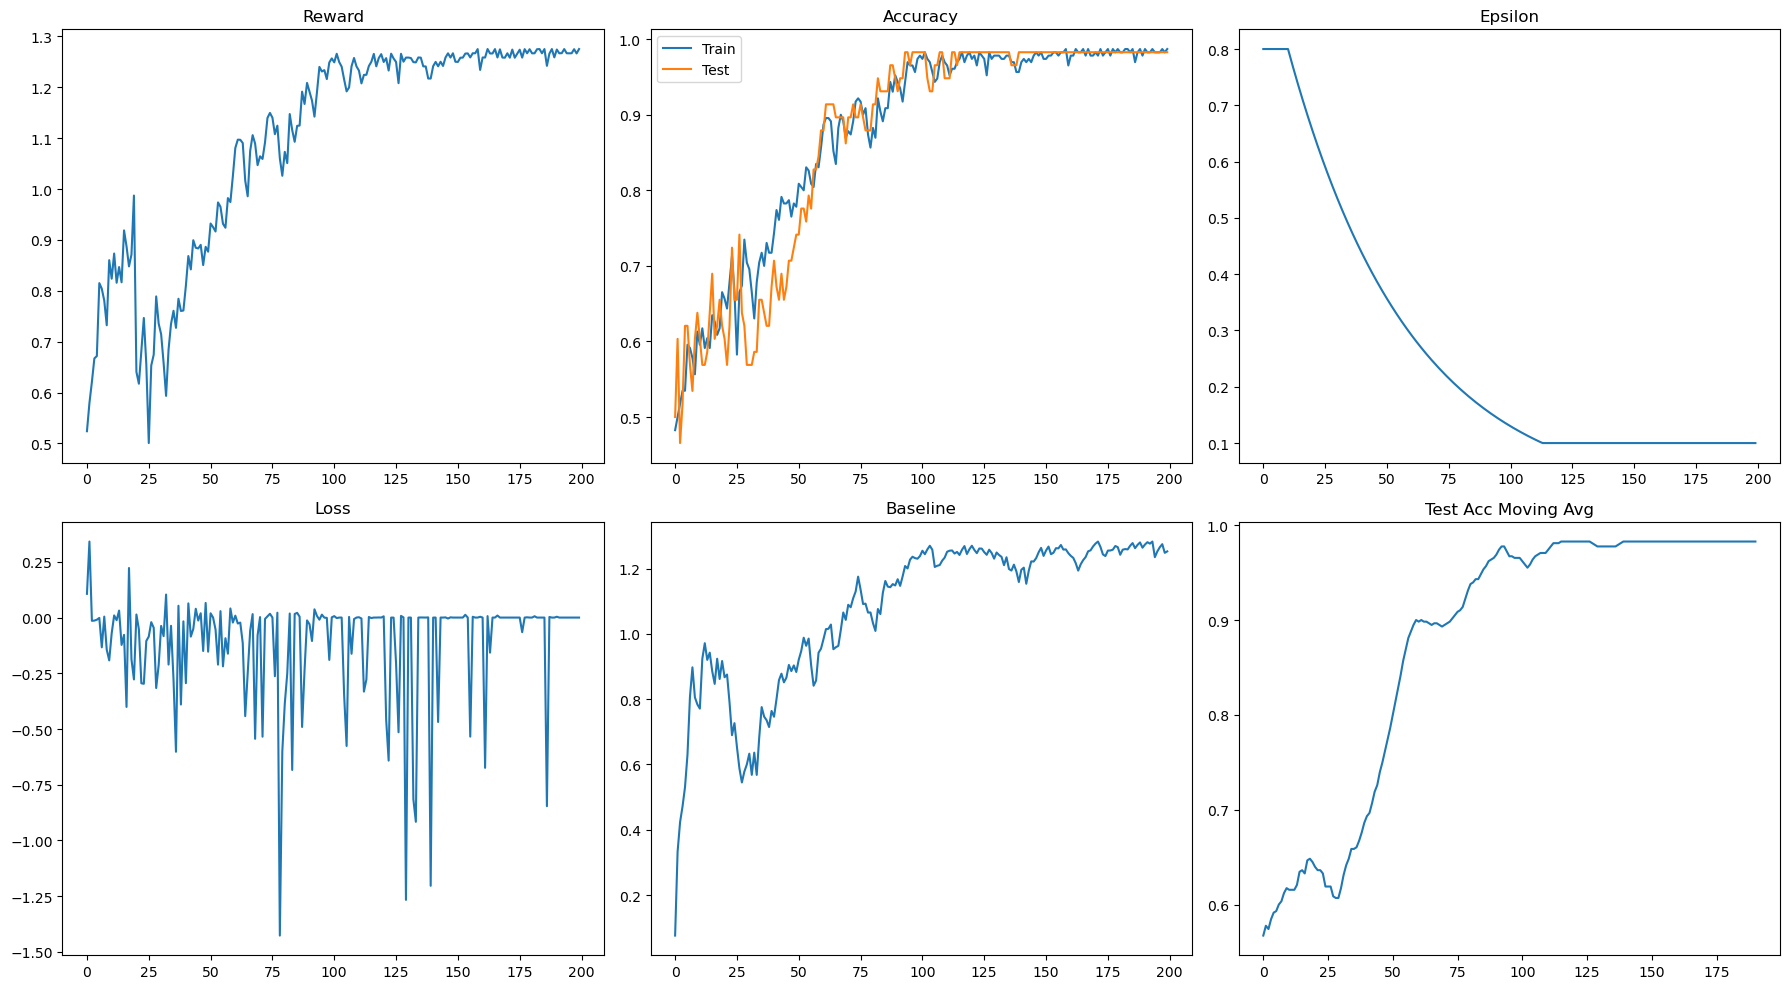

In [ ]:
import torch
import numpy as np
from transformers import GPT2ForSequenceClassification, GPT2Config, GPT2Tokenizer
import torch.nn as nn
import torch.nn.functional as F
import random
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import deque

class ImprovedRLGrammarClassifier:
    def __init__(self, tokenizer, device, max_length=25):
        self.tokenizer = tokenizer
        self.device = device
        self.max_length = max_length
        
       
        config = GPT2Config(
            vocab_size=tokenizer.vocab_size,
            bos_token_id=tokenizer.bos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            n_layer=2,
            num_labels=2,
            n_embd=768,
        )
        
        self.model = GPT2ForSequenceClassification(config).to(device)
        self.model.config.pad_token_id = tokenizer.eos_token_id
        
       
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=2e-5)
        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=30, gamma=0.8)
        
   
        self.experience_buffer = deque(maxlen=500)
        self.epsilon = 0.8
        self.epsilon_decay = 0.98
        self.epsilon_min = 0.1
        self.gamma = 0.95
        self.reward_baseline = 0.0
        self.baseline_momentum = 0.9
        
        self.learning_history = {
            'rewards': [], 'accuracy': [], 'exploration_rate': [],
            'loss': [], 'baseline': [], 'test_accuracy': []
        }
    
    def tokenize_sentences(self, sentences):
        if isinstance(sentences, str):
            sentences = [sentences]
        return self.tokenizer(
            sentences, truncation=True, padding='max_length',
            max_length=self.max_length, return_tensors="pt"
        ).to(self.device)
    
    def select_action(self, sentence, training=True):
        inputs = self.tokenize_sentences(sentence)
        with torch.no_grad():
            outputs = self.model(**inputs)
            logits = outputs.logits
            probs = F.softmax(logits, dim=-1)
        
        if training and random.random() < self.epsilon:
            action = torch.multinomial(probs, 1).item()
        else:
            action = torch.argmax(logits, dim=-1).item()
        return action, logits, probs.squeeze()
    
    def compute_reward(self, action, true_label, confidence=None, epoch=None):
        if action == true_label:
            base_reward = 1.0
            if epoch is not None and epoch < 20:
                base_reward += 0.5
        else:
            base_reward = -0.5
        
        if confidence is not None:
            if action == true_label:
                base_reward += confidence * 0.3
            else:
                base_reward -= confidence * 0.1
        return base_reward
    
    def train_on_batch(self, batch_size=16):
        if len(self.experience_buffer) < batch_size:
            return None
        
        recent_size = min(len(self.experience_buffer), batch_size * 2)
        recent_experiences = list(self.experience_buffer)[-recent_size:]
        batch = random.sample(recent_experiences, min(batch_size, len(recent_experiences)))
        
        sentences = [exp['sentence'] for exp in batch]
        actions = torch.tensor([exp['action'] for exp in batch], device=self.device)
        rewards = torch.tensor([exp['reward'] for exp in batch], dtype=torch.float, device=self.device)
        
        self.reward_baseline = (self.baseline_momentum * self.reward_baseline + 
                               (1 - self.baseline_momentum) * rewards.mean().item())
        normalized_rewards = rewards - self.reward_baseline
        
        inputs = self.tokenize_sentences(sentences)
        outputs = self.model(**inputs)
        logits = outputs.logits
        probs = F.softmax(logits, dim=-1)
        selected_probs = torch.clamp(probs.gather(1, actions.unsqueeze(-1)).squeeze(), min=1e-8)
        
        policy_loss = -(torch.log(selected_probs) * normalized_rewards).mean()
        entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=-1).mean()
        total_loss = policy_loss - 0.01 * entropy
        
        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        self.optimizer.step()
        return total_loss.item()
    
    def train_episode(self, sentences, labels, epoch):
        episode_rewards, episode_accuracy, episode_losses = [], [], []
        
        for sentence, true_label in zip(sentences, labels):
            action, _, probs = self.select_action(sentence, training=True)
            confidence = probs.max().item()
            reward = self.compute_reward(action, true_label, confidence, epoch)
            
            self.experience_buffer.append({
                'sentence': sentence, 'action': action, 'reward': reward, 'true_label': true_label
            })
            episode_rewards.append(reward)
            episode_accuracy.append(1 if action == true_label else 0)
        
        for _ in range(3):
            loss = self.train_on_batch(batch_size=16)
            if loss: episode_losses.append(loss)
            
        if epoch > 10:
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
            
        return {
            'avg_reward': np.mean(episode_rewards),
            'accuracy': np.mean(episode_accuracy),
            'avg_loss': np.mean(episode_losses) if episode_losses else 0,
            'epsilon': self.epsilon,
            'baseline': self.reward_baseline
        }
    
    def evaluate(self, test_sentences, test_labels, epoch):

        correct = 0
        confidences = []
        self.model.eval()
        
        with torch.no_grad():
            for sentence, true_label in zip(test_sentences, test_labels):
                action, _, probs = self.select_action(sentence, training=False)
                confidences.append(probs.max().item())
                if action == true_label:
                    correct += 1
        
        self.model.train()
        accuracy = correct / len(test_sentences)
        

        output_dir = f"./rl_model/epoch_{epoch}_testAcc_{accuracy:.4f}"
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            
        self.model.save_pretrained(output_dir)
        self.tokenizer.save_pretrained(output_dir)
        
        return accuracy, np.mean(confidences)

    def train(self, train_sentences, train_labels, test_sentences, test_labels, num_epochs=200):

        print(f"Epochs: {num_epochs}")
        
        for epoch in range(num_epochs):

            combined = list(zip(train_sentences, train_labels))
            random.shuffle(combined)
            s_shuffled, l_shuffled = zip(*combined)
            

            stats = self.train_episode(s_shuffled, l_shuffled, epoch)
            

            test_acc, avg_conf = self.evaluate(test_sentences, test_labels, epoch)
            

            self.learning_history['rewards'].append(stats['avg_reward'])
            self.learning_history['accuracy'].append(stats['accuracy'])
            self.learning_history['exploration_rate'].append(stats['epsilon'])
            self.learning_history['loss'].append(stats['avg_loss'])
            self.learning_history['baseline'].append(stats['baseline'])
            self.learning_history['test_accuracy'].append(test_acc)
            
            if epoch % 30 == 0 and epoch > 0:
                self.scheduler.step()
            

            print(f"Epoch {epoch:3d} | Loss: {stats['avg_loss']:.3f} | "
                  f"Train Acc: {stats['accuracy']:.3f} | Test Acc: {test_acc:.3f} | "
                  f"Epsilon: {stats['epsilon']:.3f}")
        
        print("all saved!")
        return self.learning_history

    def plot_learning_curves(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes[0,0].plot(self.learning_history['rewards']); axes[0,0].set_title('Reward')
        axes[0,1].plot(self.learning_history['accuracy'], label='Train'); 
        axes[0,1].plot(self.learning_history['test_accuracy'], label='Test'); 
        axes[0,1].set_title('Accuracy'); axes[0,1].legend()
        axes[0,2].plot(self.learning_history['exploration_rate']); axes[0,2].set_title('Epsilon')
        axes[1,0].plot(self.learning_history['loss']); axes[1,0].set_title('Loss')
        axes[1,1].plot(self.learning_history['baseline']); axes[1,1].set_title('Baseline')
        
        window = 10
        if len(self.learning_history['test_accuracy']) >= window:
            ma = np.convolve(self.learning_history['test_accuracy'], np.ones(window)/window, mode='valid')
            axes[1,2].plot(ma); axes[1,2].set_title('Test Acc Moving Avg')
            
        plt.tight_layout()
        plt.show()

def main_improved():
    y_train_numeric = [labels_ids[label] for label in y_train]
    

    train_s, test_s, train_l, test_l = train_test_split(
        new_list, y_train_numeric, test_size=0.2, random_state=42, stratify=y_train_numeric
    )
    

    trainer = ImprovedRLGrammarClassifier(tokenizer, device, max_length=max_length)
    

    history = trainer.train(train_s, train_l, test_s, test_l, num_epochs=epochs)
    

    trainer.plot_learning_curves()
    
    return trainer, history


trainer_improved, history_improved = main_improved()

## plot

In [ ]:
cla_acc_list = []
cla_models_list = []
cla_models_path = './rl_model/'
for name_id in range(200):
    for name in os.listdir(cla_models_path):
        if name[0:3] == 'epo' and name.split('_')[1] == str(name_id) :#and (not (float(name.split('_')[5]) in cla_acc_list)):
            cla_models_list.append(cla_models_path+name)
            cla_acc_list.append(float(name.split('_')[3]))
        #break
    #break

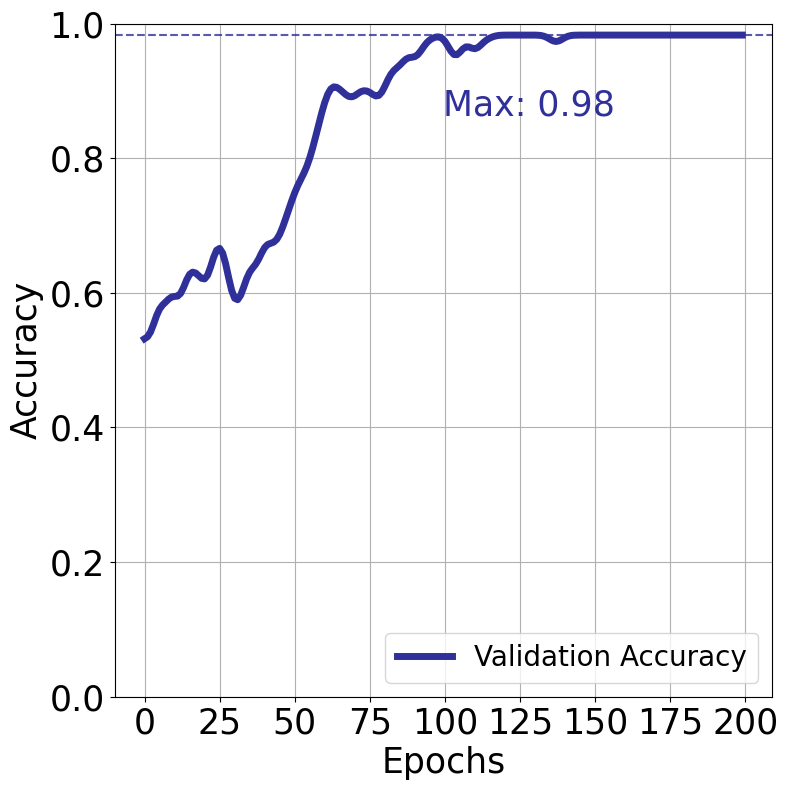

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d


val_acc = cla_acc_list #all_acc['val_acc']

epochs = range(200)#range(1, len(train_acc) + 1)


plt.style.use('default')
plt.figure(figsize=(8, 8))


val_acc_smooth = gaussian_filter1d(val_acc, sigma=2)


plt.plot(epochs, val_acc_smooth, label='Validation Accuracy', color='#30309A', linestyle='-', linewidth=5)


max_val_y = max(val_acc_smooth)
max_val_x = epochs[list(val_acc_smooth).index(max_val_y)]  # 根据索引找到对应的 epoch


plt.axhline(y=max_val_y, color='#30309A', linestyle='--', linewidth=1.5, alpha=0.8)



plt.text(max_val_x + 5, max_val_y-0.12, f'Max: {max_val_y:.2f}', 
         fontsize=25, color='#30309A', ha='center')


plt.xticks(fontsize=25) 
plt.yticks(fontsize=25)
plt.ylim(0, 1.0)  
plt.xlabel('Epochs', fontsize=25)
plt.ylabel('Accuracy', fontsize=25)
plt.grid(True)
plt.legend(loc='lower right', fontsize=20)


plt.tight_layout()
plt.savefig('./rl_model_with_max.png', dpi=600)
plt.show()
